## Demographic characterization Q1 - Q8

In [1]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
skills_long = pd.read_csv(U.DATA_PROC / "skills.csv")

In [2]:
def freq_table(series: pd.Series, label: str, order=None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).fillna(0).astype(int)
    pct = (counts / counts.sum() * 100).round(1)
    out = pd.DataFrame({"Category": counts.index, "n": counts.values, "%": pct.values})
    out.insert(0, "Variable", "")
    out.iloc[0, 0] = label
    return out

blocks = [
    freq_table(df["gender_norm"], "Gender"),
    freq_table(df["age_band"], "Age band",
               order=["18-24 years", "25-34 years", "35-44 years", "45-54 years", "55-64 years"]),
    freq_table(df["norm_country"], "Country"),
    freq_table(df["education_norm"], "Education"),
    freq_table(df["role_group"], "Role"),
    freq_table(df["seniority_norm"], "Seniority"),
]
demo_table = pd.concat(blocks, ignore_index=True)
demo_table = demo_table[demo_table["n"] > 0].reset_index(drop=True)
demo_table

,Variable,Category,n,%
0,Gender,male,45,80.4
1,,female,11,19.6
2,Country,Brazil,42,75.0
3,,United States,5,8.9
4,,Germany,4,7.1
5,,France,2,3.6
6,,Ireland,1,1.8
7,,Colombia,1,1.8
8,,China,1,1.8
9,Education,Doctoral student,18,32.1


In [3]:
df["n_projects"].value_counts()

n_projects
3     10
2      9
5      6
6      5
4      5
1      4
10     3
8      3
0      2
40     2
15     2
7      2
13     1
11     1
25     1
Name: count, dtype: int64

## Q8 — Self-assessed skill level in data processing activities

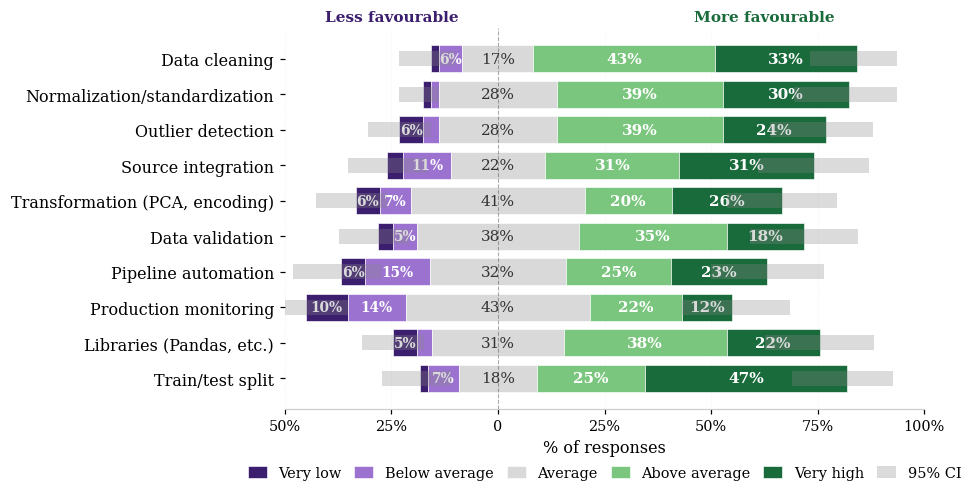

In [4]:
import matplotlib.pyplot as plt

skills_renamed = skills_long.copy()
_skill_items = list(U.SKILL_LABELS_PT.keys())

_skill_ci = U._bootstrap_ci(
    skills_renamed.dropna(),
    "activity",
    "skill",
    _skill_items,
    top_levels=[4, 5],
    bottom_levels=[1, 2],
)

fig = U.diverging_stacked(
    skills_renamed.dropna(),
    item_col="activity",
    value_col="skill",
    item_labels=U.SKILL_LABELS_PT,
    level_labels=["Very low", "Below average", "Average", "Above average", "Very high"],
    figsize=(7.5, 4.5),
    ci_df=_skill_ci,
)

U.save_fig(fig, "skills_diverging")
plt.show()